# Quick Reference Guide for Low-Data CV Plotting
# =================================================

## Overview
This guide shows you how to visualize your low-data regime cross-validation results
with professional-looking plots featuring shaded error regions.

## Your Data Structure
After running your CV, you should have:
```python
results_df, predictions_df = run_cross_validation_from_precomputed(
    X_normalized=X_normalized,
    obs=adata.obs,
    folds=folds,  # donor-level folds (e.g., 5 donors)
    Ns=[2, 4, 8, 16, 32, 64, 128, 256, 512],  # cells per class
    n_bootstrap=10,  # bootstrap repeats per fold
    label_col="Condition",
    feature_extractors=feature_extractors,  # {'raw': ..., 'scGPT': ..., etc.}
)
```

In [28]:
import pandas as pd
results_df = pd.read_csv("/sci/backup/dandanbz/haya.benhayon/IBM/biomed-multi-omic/notebooks/disease_vs_celltype/result_df/Single_prediction_task_rawBMFM_N_B_29_01.csv")
results_df


,fold,N,bootstrap,feature_type,n_train,n_dev,AUROC,AUPRC,balanced_acc,F1,...,log_loss,brier,TP,FP,TN,FN,test_pos_rate,mean_donor_acc,worst_donor_acc,std_donor_acc
0,H123,2,1,raw_lognorm,4,11956,0.677689,0.404467,0.665361,0.557323,...,15.235958,0.429989,3240,4805,3569,342,0.299599,0.520861,0.256188,0.247969
1,H123,2,1,random_proj50,4,11956,0.535382,0.329036,0.533252,0.370762,...,13.156407,0.414698,1471,2882,5492,2111,0.299599,0.606948,0.410664,0.115535
2,H123,2,1,embedding_bmfm,4,11956,0.756918,0.470172,0.755693,0.637305,...,12.017328,0.334034,3509,3921,4453,73,0.299599,0.612407,0.100583,0.325231
3,H123,2,2,raw_lognorm,4,11956,0.472768,0.282054,0.477353,0.070793,...,12.496416,0.348977,159,751,7623,3423,0.299599,0.730844,0.044389,0.391802
4,H123,2,2,random_proj50,4,11956,0.411280,0.257202,0.444210,0.270297,...,15.846136,0.498010,1112,3534,4840,2470,0.299599,0.525071,0.310441,0.131413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,H032,1024,4,random_proj50,2048,217,0.564747,0.246412,0.519259,0.223881,...,0.979430,0.328270,15,90,98,14,0.133641,0.563291,0.283582,0.180391
1796,H032,1024,4,embedding_bmfm,2048,217,0.632520,0.195950,0.590976,0.278689,...,9.545705,0.400842,17,76,112,12,0.133641,0.623262,0.417910,0.140085
1797,H032,1024,5,raw_lognorm,2048,217,0.801266,0.339507,0.767608,0.473118,...,5.411640,0.222393,22,42,146,7,0.133641,0.752192,0.636364,0.076925
1798,H032,1024,5,random_proj50,2048,217,0.597212,0.295189,0.547047,0.246575,...,1.117231,0.359888,18,99,89,11,0.133641,0.565540,0.313433,0.188916


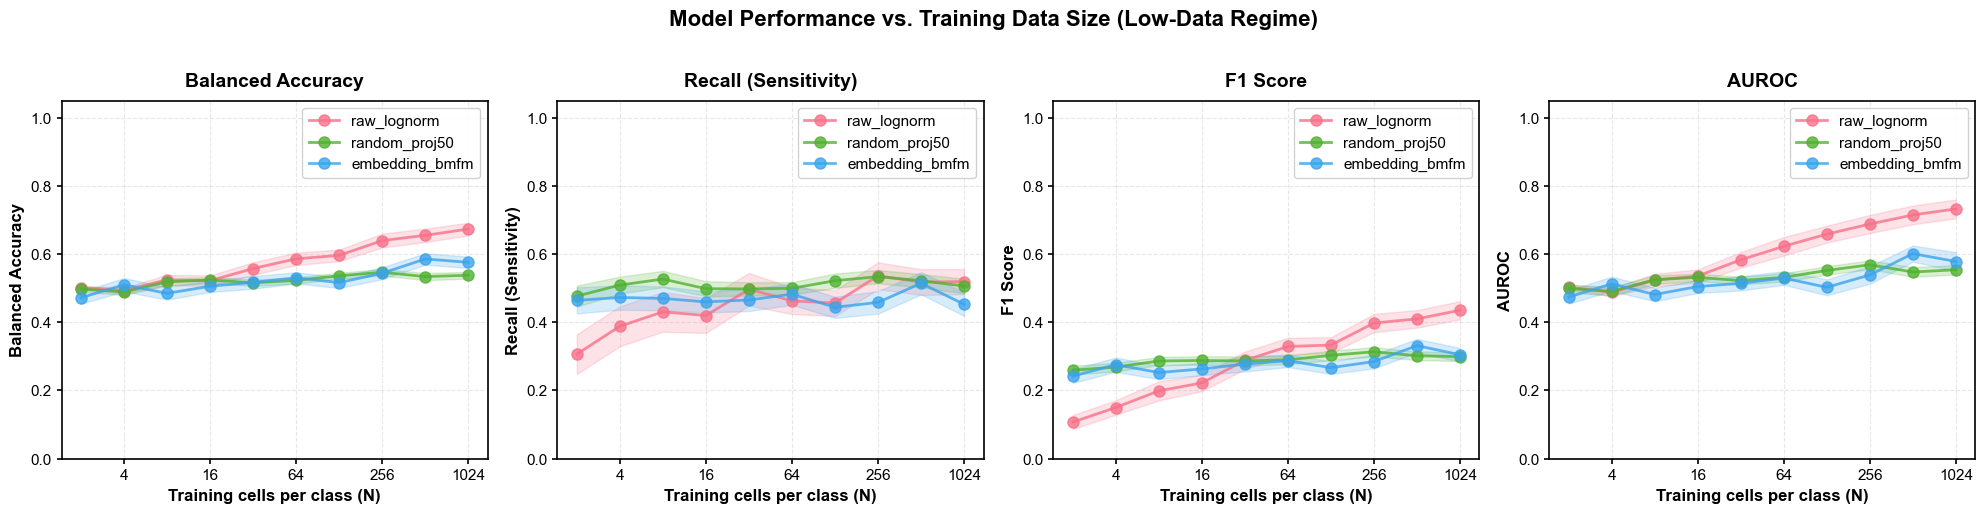

In [29]:
from plot_low_data_cv import plot_low_data_performance
import matplotlib.pyplot as plt

fig, axes = plot_low_data_performance(results_df)
plt.show()

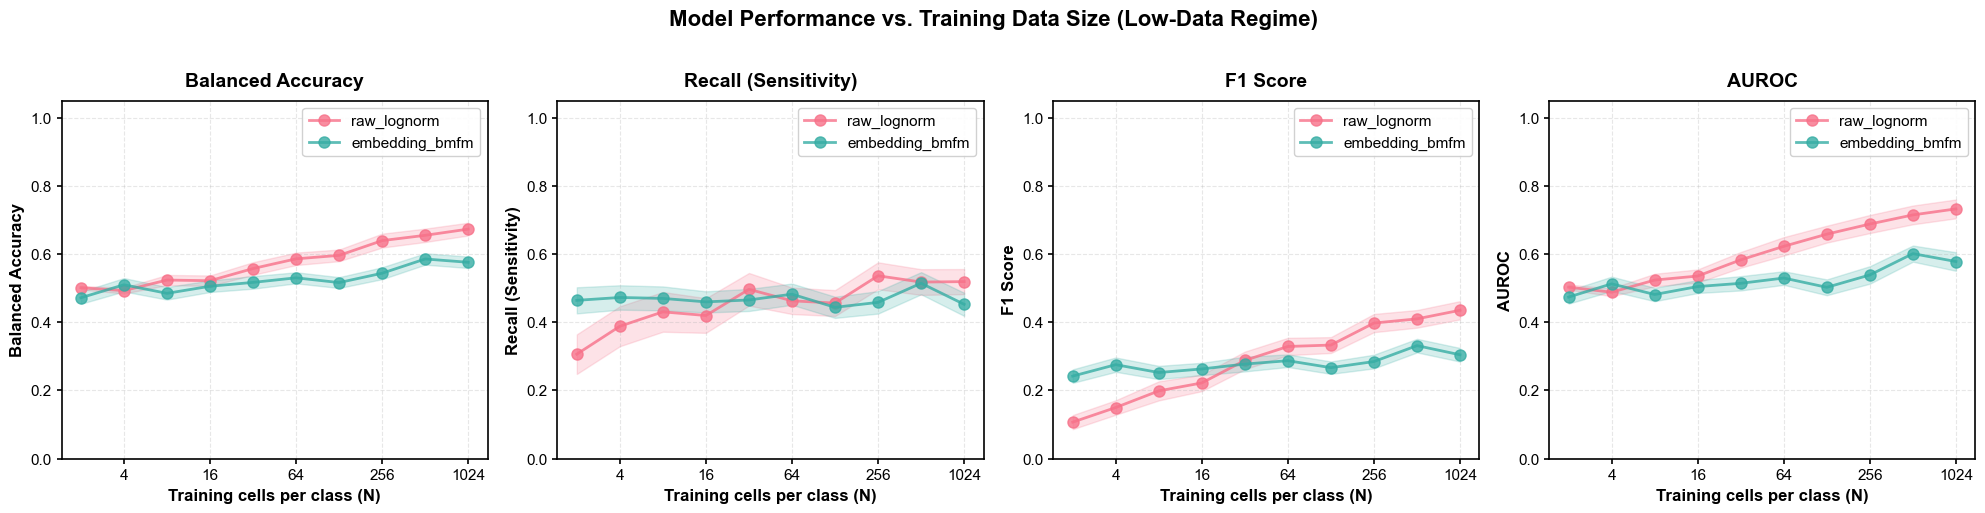

In [30]:
from plot_low_data_cv import plot_low_data_performance

fig, axes = plot_low_data_performance(
    results_df,
    feature_types=['raw_lognorm', 'embedding_bmfm'],  # None = all
    figsize=(20, 5)
)
plt.show()

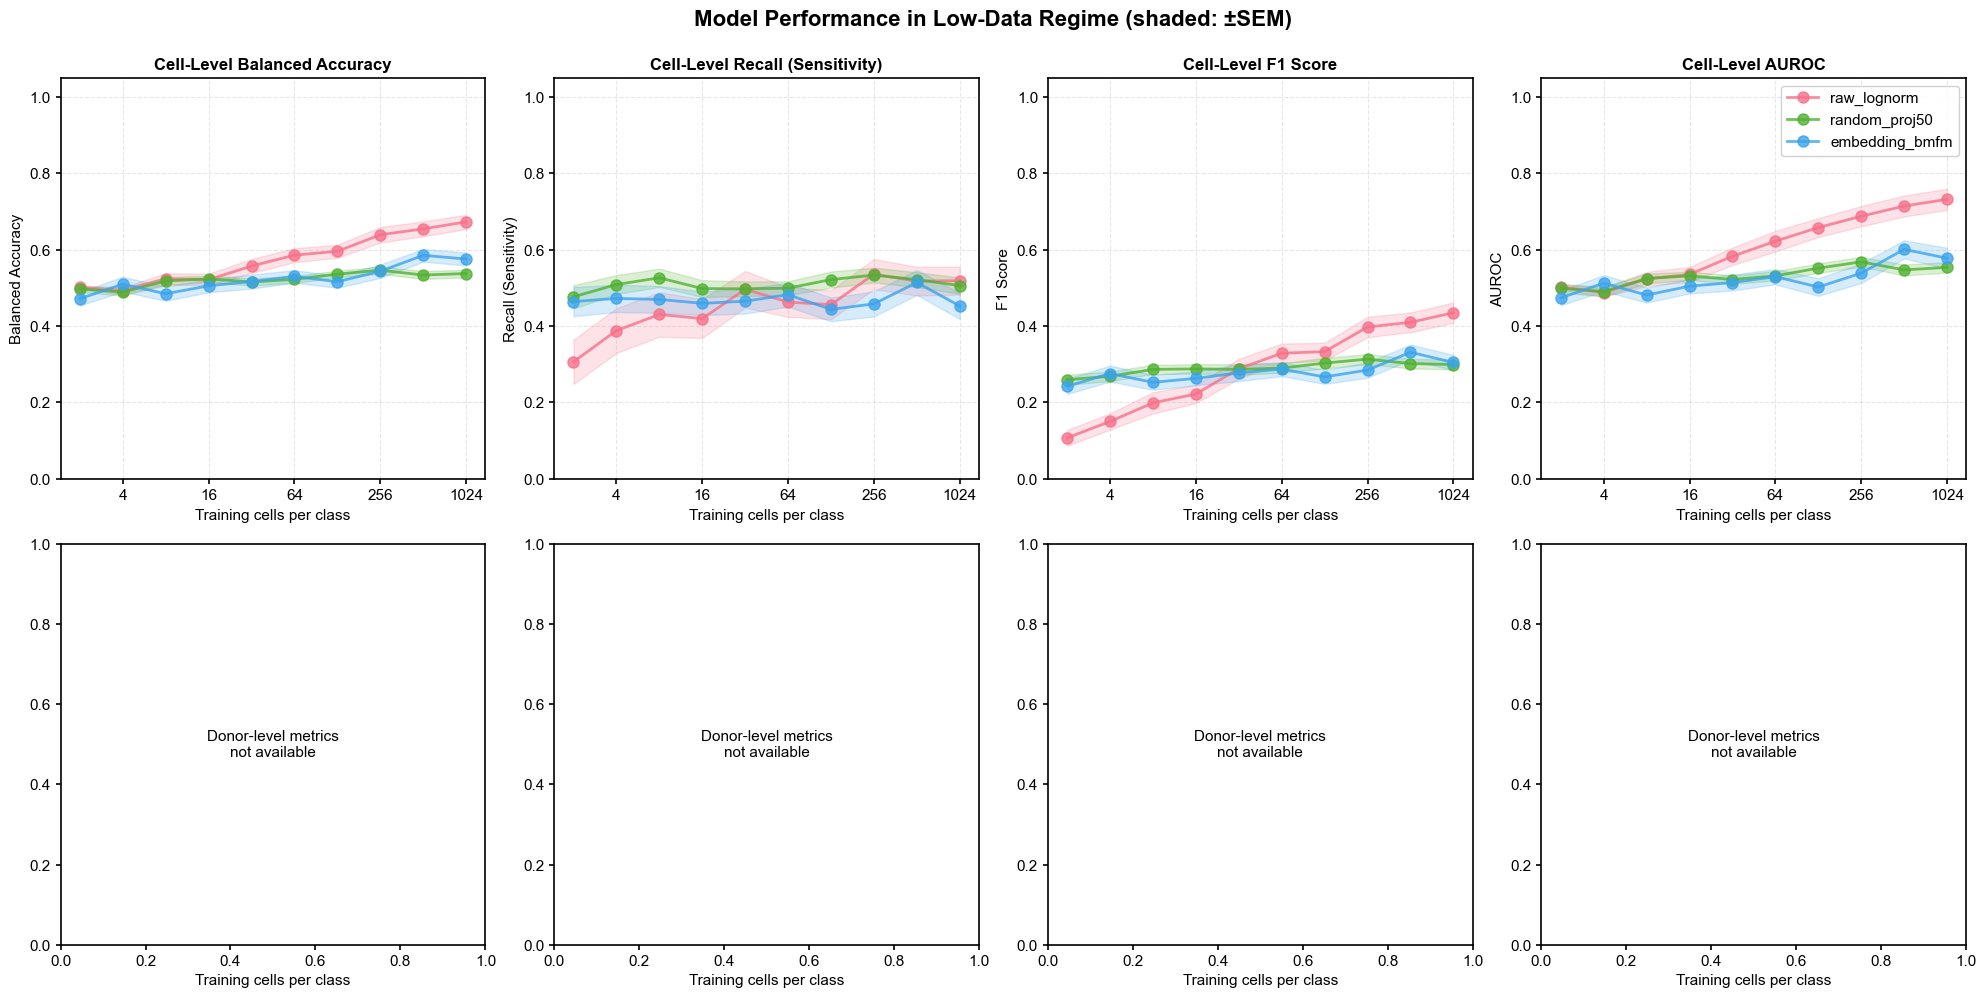

In [31]:
from plot_low_data_cv import plot_low_data_performance_detailed

fig, axes = plot_low_data_performance_detailed(
    results_df,
    error_type='sem',  # or 'std'
    figsize=(20, 10)
)
plt.show()

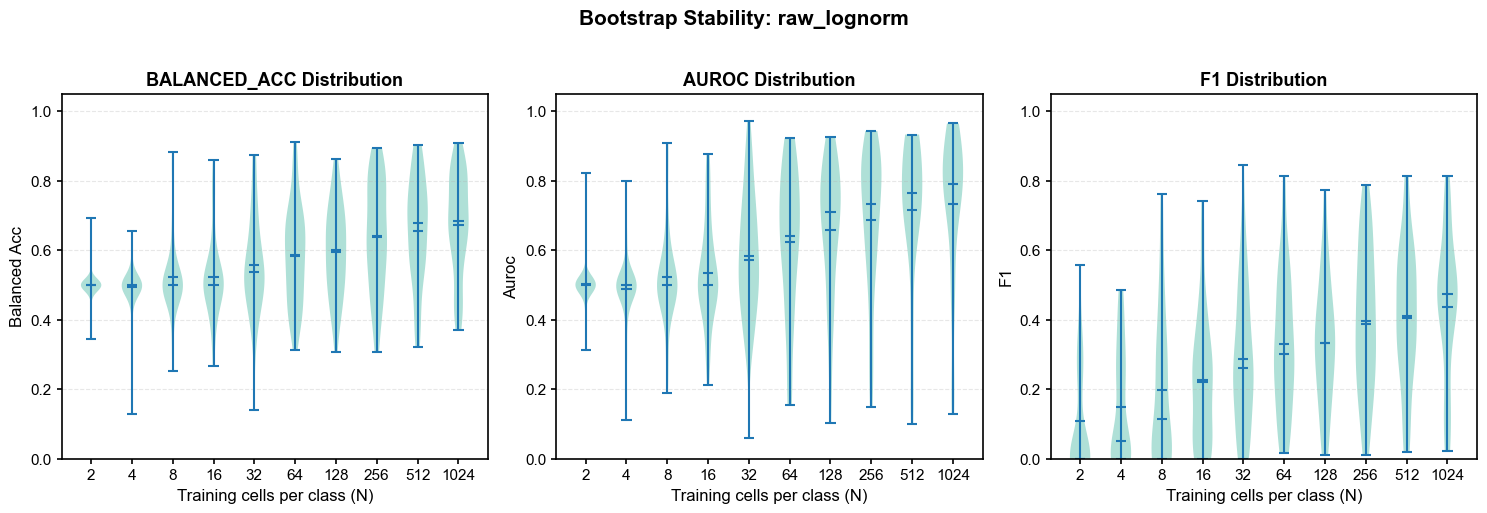

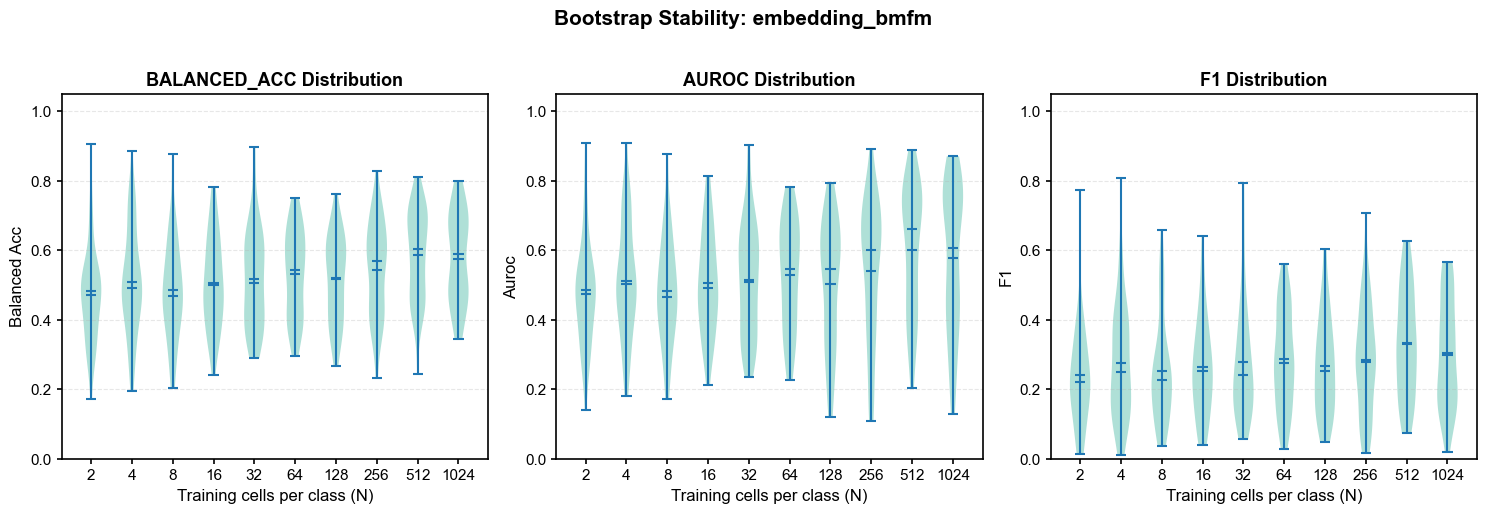

In [33]:
from plot_low_data_cv import plot_bootstrap_stability

for feature in ['raw_lognorm', 'embedding_bmfm']:
    fig, axes = plot_bootstrap_stability(
        results_df,
        feature_type=feature,
        #N_values=[2, 8, 32, 128, 512]  # None = all
    )
    plt.show()

Saved to fig_performance.png


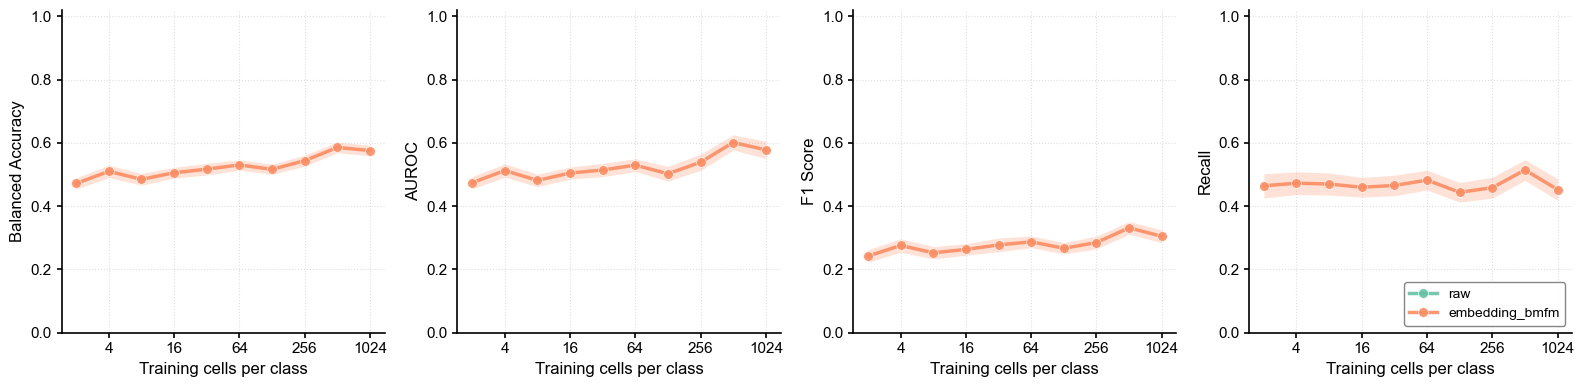

In [34]:
from plot_publication_quality import plot_publication_quality

fig, axes = plot_publication_quality(
    results_df,
    feature_types=['raw', 'embedding_bmfm'],
    color_palette='Set2',  # or 'tab10', 'husl', etc.
    save_path="fig_performance.png"
)

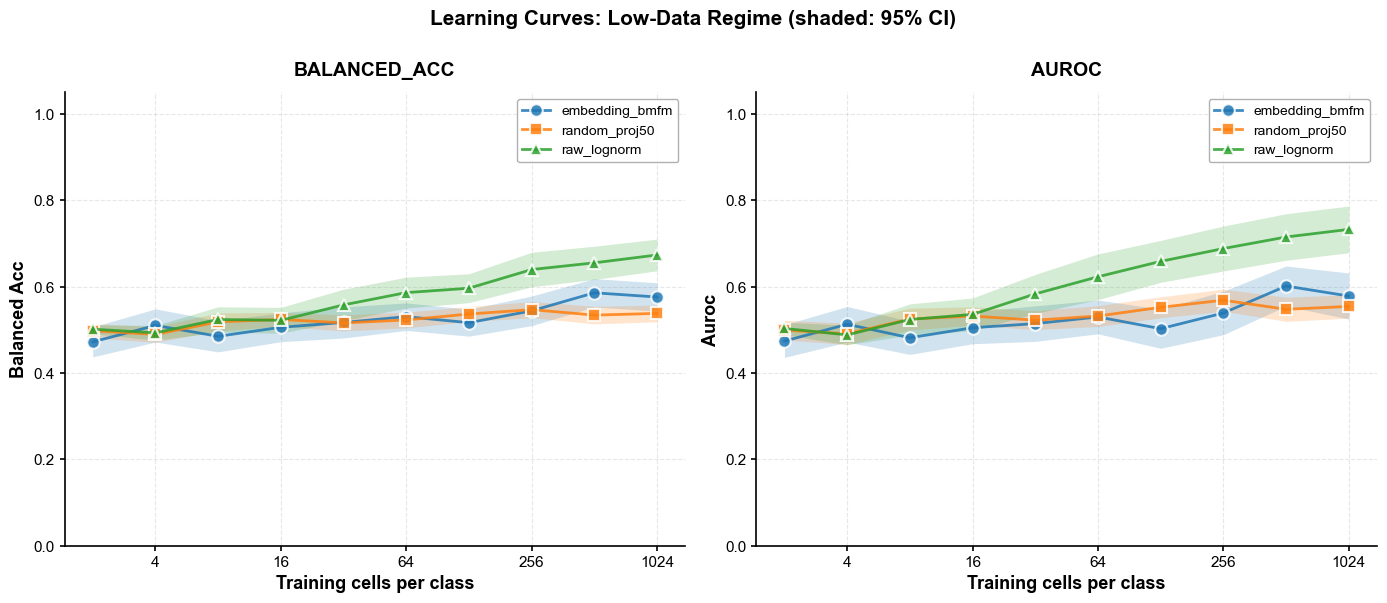

In [35]:
from plot_publication_quality import plot_learning_curves_comparison

fig, axes = plot_learning_curves_comparison(
    results_df,
    metrics=['balanced_acc', 'AUROC'],
    show_confidence=True
)
plt.show()

Saved figures with prefix: low_data_analysis


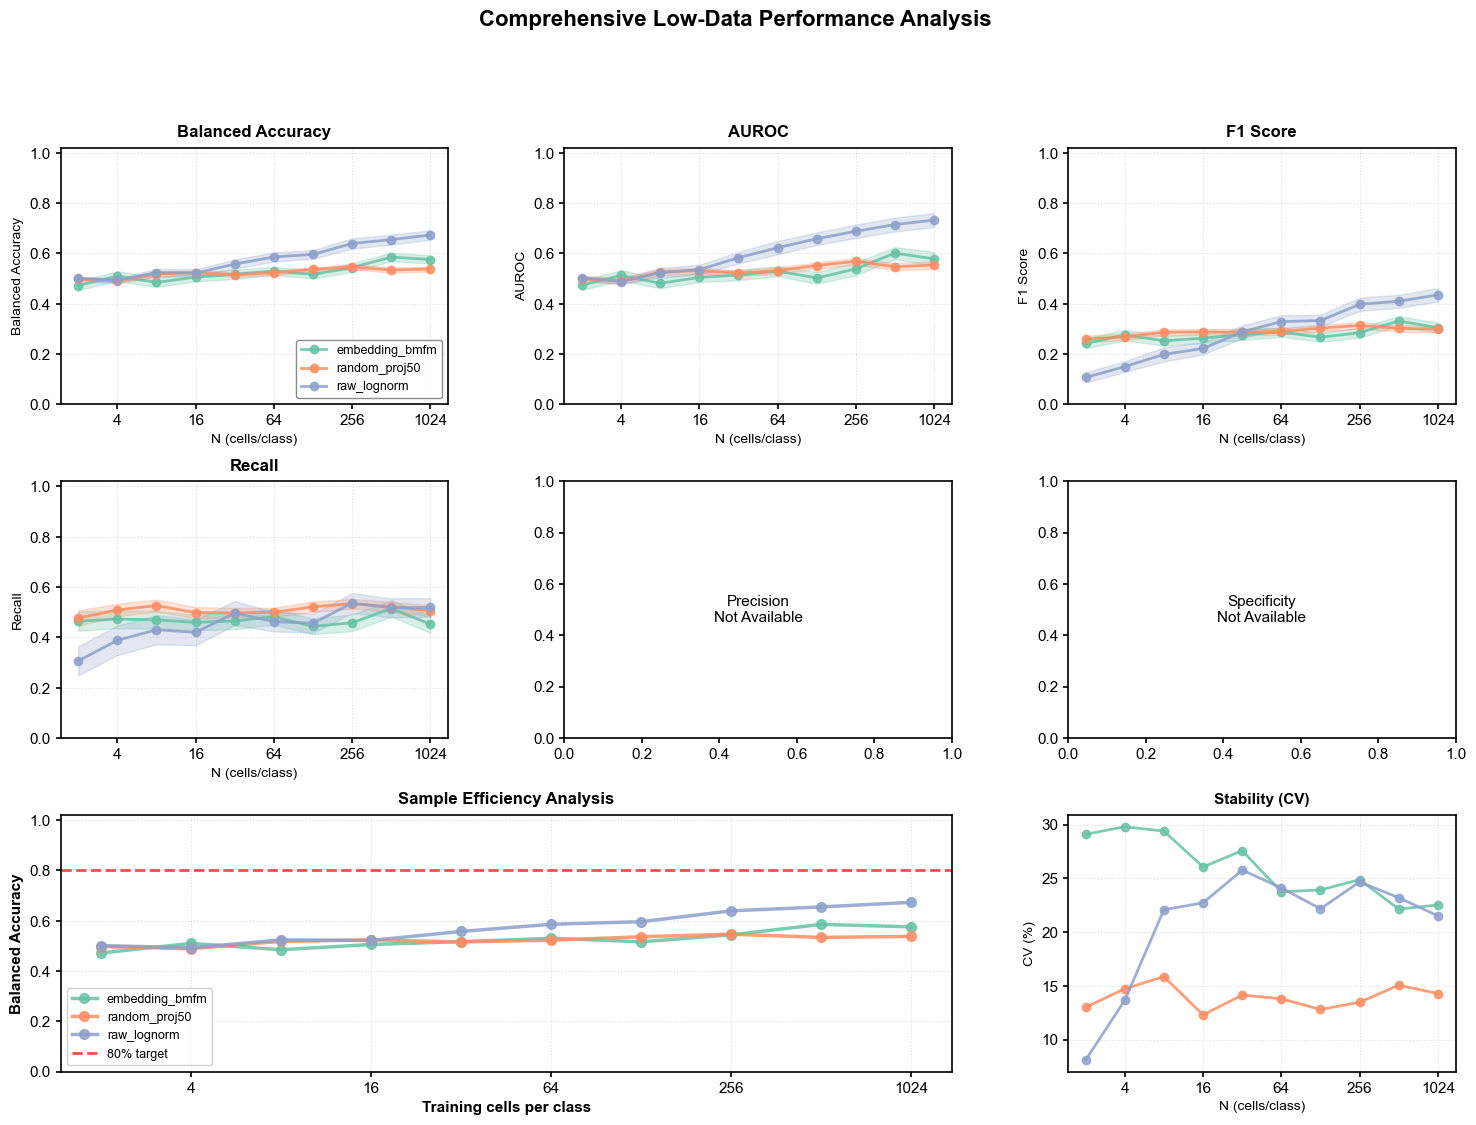

In [36]:
from plot_publication_quality import create_summary_figure

fig = create_summary_figure(
    results_df,
    save_prefix="low_data_analysis"  # saves PNG and PDF
)
plt.show()

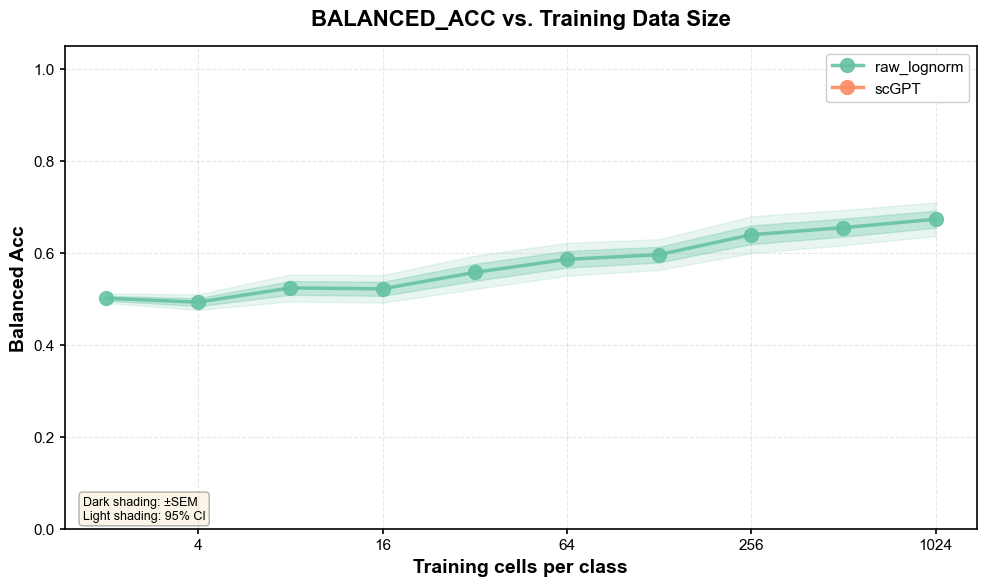

In [37]:
import seaborn as sns
import numpy as np
def plot_metric_comparison(results_df, metric='balanced_acc', 
                          feature_types=None, figsize=(10, 6)):
    """
    Create a focused plot comparing feature types on a single metric.
    """
    if feature_types is not None:
        df = results_df[results_df["feature_type"].isin(feature_types)].copy()
    else:
        df = results_df.copy()
        feature_types = df["feature_type"].unique()
    
    colors = sns.color_palette("Set2", len(feature_types))
    color_map = dict(zip(feature_types, colors))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    for feature_type in feature_types:
        feature_df = df[df["feature_type"] == feature_type]
        
        grouped = feature_df.groupby("N")[metric].agg([
            ("mean", "mean"),
            ("sem", lambda x: x.std() / np.sqrt(len(x))),
            ("count", "count")
        ]).reset_index().sort_values("N")
        
        N_values = grouped["N"].values
        means = grouped["mean"].values
        sems = grouped["sem"].values
        counts = grouped["count"].values
        
        # Calculate 95% confidence interval
        ci_95 = 1.96 * sems
        
        color = color_map[feature_type]
        ax.plot(N_values, means, 'o-', color=color, 
               label=f"{feature_type}",# (n={counts[0]} per N)", 
               linewidth=2.5, markersize=10, alpha=0.9)
        ax.fill_between(N_values, means - ci_95, means + ci_95, 
                       color=color, alpha=0.15)
        ax.fill_between(N_values, means - sems, means + sems, 
                       color=color, alpha=0.3)
    
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Training cells per class", fontsize=14, fontweight='bold')
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=14, fontweight='bold')
    ax.set_title(f"{metric.upper()} vs. Training Data Size", 
                fontsize=16, fontweight='bold', pad=15)
    ax.grid(True, linestyle="--", alpha=0.3, which='both')
    ax.legend(loc='best', frameon=True, framealpha=0.95, fontsize=11)
    ax.xaxis.set_major_formatter(plt.ScalarFormatter())
    
    if metric in ["balanced_acc", "recall", "F1", "AUROC"]:
        ax.set_ylim([0, 1.05])
    
    # Add note about shading
    ax.text(0.02, 0.02, "Dark shading: ±SEM\nLight shading: 95% CI", 
           transform=ax.transAxes, fontsize=9, 
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    return fig, ax
    
fig, ax = plot_metric_comparison(
    results_df,
    metric='balanced_acc',
    feature_types=['raw_lognorm', 'scGPT']
)
plt.show()

In [38]:
results_df

,fold,N,bootstrap,feature_type,n_train,n_dev,AUROC,AUPRC,balanced_acc,F1,...,log_loss,brier,TP,FP,TN,FN,test_pos_rate,mean_donor_acc,worst_donor_acc,std_donor_acc
0,H123,2,1,raw_lognorm,4,11956,0.677689,0.404467,0.665361,0.557323,...,15.235958,0.429989,3240,4805,3569,342,0.299599,0.520861,0.256188,0.247969
1,H123,2,1,random_proj50,4,11956,0.535382,0.329036,0.533252,0.370762,...,13.156407,0.414698,1471,2882,5492,2111,0.299599,0.606948,0.410664,0.115535
2,H123,2,1,embedding_bmfm,4,11956,0.756918,0.470172,0.755693,0.637305,...,12.017328,0.334034,3509,3921,4453,73,0.299599,0.612407,0.100583,0.325231
3,H123,2,2,raw_lognorm,4,11956,0.472768,0.282054,0.477353,0.070793,...,12.496416,0.348977,159,751,7623,3423,0.299599,0.730844,0.044389,0.391802
4,H123,2,2,random_proj50,4,11956,0.411280,0.257202,0.444210,0.270297,...,15.846136,0.498010,1112,3534,4840,2470,0.299599,0.525071,0.310441,0.131413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,H032,1024,4,random_proj50,2048,217,0.564747,0.246412,0.519259,0.223881,...,0.979430,0.328270,15,90,98,14,0.133641,0.563291,0.283582,0.180391
1796,H032,1024,4,embedding_bmfm,2048,217,0.632520,0.195950,0.590976,0.278689,...,9.545705,0.400842,17,76,112,12,0.133641,0.623262,0.417910,0.140085
1797,H032,1024,5,raw_lognorm,2048,217,0.801266,0.339507,0.767608,0.473118,...,5.411640,0.222393,22,42,146,7,0.133641,0.752192,0.636364,0.076925
1798,H032,1024,5,random_proj50,2048,217,0.597212,0.295189,0.547047,0.246575,...,1.117231,0.359888,18,99,89,11,0.133641,0.565540,0.313433,0.188916


In [39]:
from example_plotting_usage import plot_relative_improvement

fig, axes = plot_relative_improvement(
    results_df,
    baseline_feature='raw',  # compare everything to raw
    comparison_features=['scGPT', 'Geneformer']
)
plt.show()

NameError: name 'results_df' is not defined

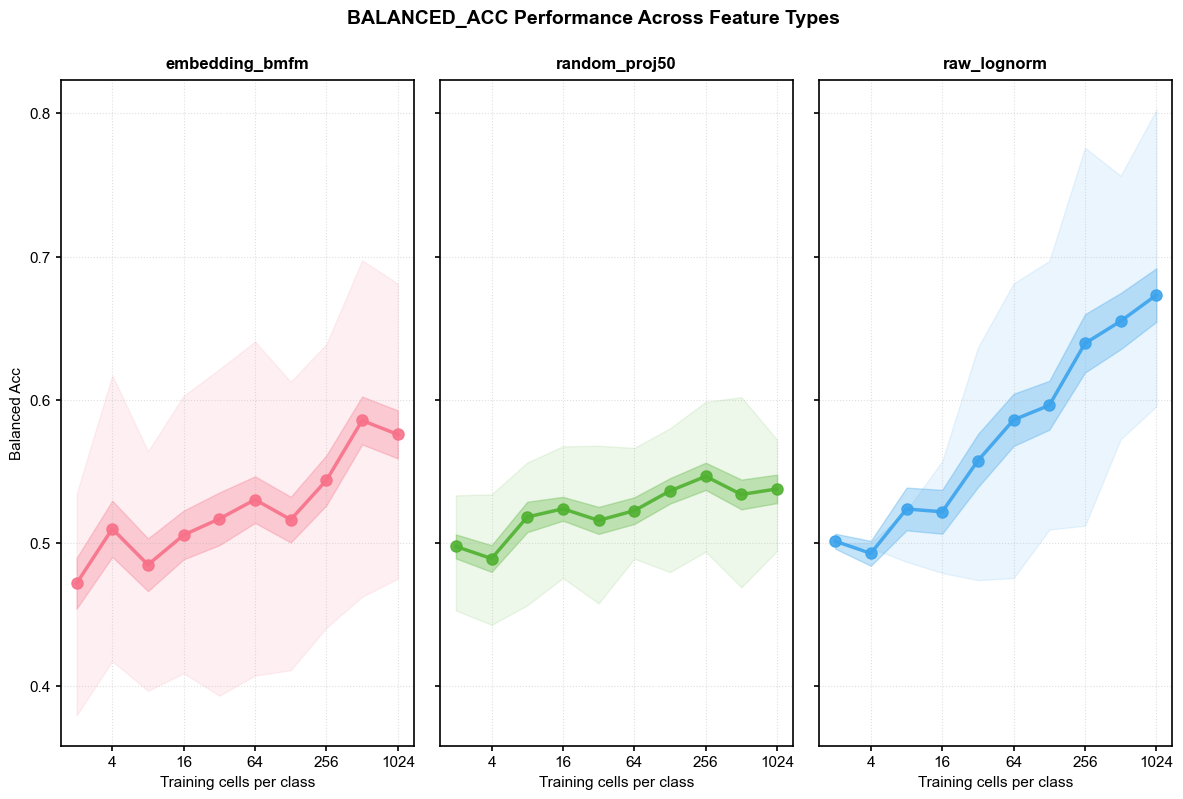

In [40]:
from plot_publication_quality import plot_faceted_comparison

fig, axes = plot_faceted_comparison(
    results_df,
    metric='balanced_acc',
    figsize=(12, 8)
)
plt.show()

In [ ]:
from example_plotting_usage import print_summary_table

In [41]:
def print_summary_table(results_df, N_values=None):
    """
    Print a summary table of performance across N values.
    """
    if N_values is None:
        N_values = sorted(results_df['N'].unique())
    
    for feature_type in results_df['feature_type'].unique():
        print(f"\n{'='*80}")
        print(f"Feature Type: {feature_type}")
        print(f"{'='*80}")
        
        feature_df = results_df[results_df['feature_type'] == feature_type]
        
        summary = []
        for N in N_values:
            N_df = feature_df[feature_df['N'] == N]
            if len(N_df) == 0:
                continue
            
            row = {
                'N': N,
                'n_samples': len(N_df),
                'AUROC': f"{N_df['AUROC'].mean():.3f} ± {N_df['AUROC'].std():.3f}",
                'Balanced_Acc': f"{N_df['balanced_acc'].mean():.3f} ± {N_df['balanced_acc'].std():.3f}",
                'F1': f"{N_df['F1'].mean():.3f} ± {N_df['F1'].std():.3f}",
                'Recall': f"{N_df['recall'].mean():.3f} ± {N_df['recall'].std():.3f}",
            }
            summary.append(row)
        
        summary_df = pd.DataFrame(summary)
        print(summary_df.to_string(index=False))
    print("\n")
print_summary_table(results_df)


Feature Type: raw_lognorm
   N  n_samples         AUROC  Balanced_Acc            F1        Recall
   2         60 0.503 ± 0.056 0.501 ± 0.041 0.107 ± 0.160 0.306 ± 0.450
   4         60 0.488 ± 0.090 0.493 ± 0.067 0.150 ± 0.164 0.388 ± 0.454
   8         60 0.524 ± 0.143 0.524 ± 0.116 0.199 ± 0.217 0.431 ± 0.451
  16         60 0.536 ± 0.150 0.522 ± 0.119 0.222 ± 0.187 0.420 ± 0.394
  32         60 0.583 ± 0.178 0.558 ± 0.144 0.288 ± 0.200 0.497 ± 0.371
  64         60 0.623 ± 0.209 0.586 ± 0.141 0.329 ± 0.196 0.463 ± 0.300
 128         60 0.658 ± 0.192 0.596 ± 0.132 0.333 ± 0.180 0.456 ± 0.294
 256         60 0.688 ± 0.205 0.639 ± 0.158 0.398 ± 0.207 0.536 ± 0.305
 512         60 0.715 ± 0.213 0.655 ± 0.152 0.410 ± 0.200 0.518 ± 0.292
1024         60 0.732 ± 0.214 0.673 ± 0.145 0.435 ± 0.207 0.519 ± 0.285

Feature Type: random_proj50
   N  n_samples         AUROC  Balanced_Acc            F1        Recall
   2         60 0.499 ± 0.089 0.498 ± 0.065 0.260 ± 0.102 0.477 ± 0.238
   4    